Neste notebook estarei implementando uma ACGAN (Auxiliary Classifier GAN)
que deve ser treinada em cima da base de dados MNIST, e aprender a gerar novas imagens de digitos manuscritos, com o controle de qual número será gerado:

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import ConcatDataset, DataLoader
import torchvision.transforms as transforms
torch.__version__

'2.10.0+cu130'

In [2]:
torch.manual_seed(123)

In [3]:
transform = transforms.ToTensor()

trainDataset = datasets.MNIST(root = '../', train = True, download = True, 
                       transform = transform)
testDataset = datasets.MNIST(root = '../', train = False, download = True, 
                       transform = transform)
# dataset único
fullDataset = ConcatDataset([trainDataset, testDataset])

loader = DataLoader(fullDataset, batch_size = 128, shuffle = True)

Definição da Rede Geradora:

In [4]:
class Gerador(nn.Module):
    def __init__(self):
        super().__init__()

        self.z_dim = 100
        self.num_classes = 10

        # Vamos usar one-hot: y vira vetor de tamanho 10
        in_features = self.z_dim + self.num_classes

        self.model = nn.Sequential(
            # 100 números aleatórios para 64 da 1a camada oculta
            nn.Linear(in_features, 64),
            # LeakyReLU: Para numeros positivos funciona como ReLU.
            # Para numeros negativos, multiplica a entrada por um slope definido em seu parametro
            # Aqui nesse caso, o slope foi 0.2, ou seja:
            # Caso a entrada seja negativa, ela será multiplicada por 0.2 para a saída.
            # O resultado é um número negativo maior (menos negativo) do que a entrada, caso ela seja negativa.
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(32, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(64, 100),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(100, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            # 28 * 28: Dimensionalidade das imagens da base MNIST
            nn.Linear(128, 28*28),
            # Função de ativação da saída: Tangente hiperbolica, saída fica entre -1 e 1.
            # Costuma funcionar melhor para GANs pois o treinamento é mais estável e rápido do que Sigmoid,
            # Devido ao valor pequeno do gradiente que ocorre em Sigmoid quando os valores estão próximos de 0 ou 1.
            # Para usar Tanh, as imagens de treino do discriminador também precisam ficar entre -1 e 1.
            nn.Tanh()
         )

    def forward(self, ruido, labels):
        # labels: [B] com valores 0..9
        onehot = torch.zeros(labels.size(0), self.num_classes, device=labels.device)
        onehot.scatter_(1, labels.view(-1, 1), 1.0)

        x = torch.cat((ruido, onehot), dim=1)  # [B, 110]
        out = self.model(x)
        out = out.view(-1, 1, 28, 28)
        return out

Definição da Rede Discriminadora e classificadora:

In [5]:
class Discriminador(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3,3)),
            nn.ReLU(),
            nn.BatchNorm2d(num_features=32),
            nn.MaxPool2d(kernel_size=(2, 2)),
            
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3,3)),
            nn.ReLU(),
            nn.BatchNorm2d(num_features=32),
            nn.MaxPool2d(kernel_size=(2, 2)),

            nn.Flatten(),
        )

        # 64 * 7 * 7 = 3136
        self.shared = nn.Sequential(
            nn.Linear(in_features = 5 * 5 * 32, out_features = 128),
            nn.ReLU(),
            nn.Dropout(p = 0.2),

            nn.Linear(in_features = 128, out_features = 128),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
        )

        # Cabeça adversarial: 1 logit (real/fake)
        self.adv_head = nn.Linear(128, 1)

        # Cabeça de classe: 10 logits
        self.cls_head = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = self.shared(x)

        adv_out = self.adv_head(x)  # [B, 1]
        cls_out = self.cls_head(x)  # [B, 10]
        return adv_out, cls_out

Treinamento dos modelos:

In [6]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

G = Gerador().to(device)
D = Discriminador().to(device)

GOptimizer = optim.Adam(G.parameters(), lr = 0.002)
DOptimizer = optim.Adam(D.parameters(), lr = 0.002)

# Aplica Sigmoid intermanete e usa Binary cross entropy
# Segundo a doc do pytorch, é mais estável do que usar BCELoss com uma fç de ativação Sigmoid na ultima camada.
# Logits: Dados não tratados na ultima camada. Ou seja, dados que não passaram ainda por uma fç de ativação na ultima camada.

# Criterio da subrede adversaria
criterion_adv = nn.BCEWithLogitsLoss()
# Criterio da subrede classificadora
criterion_cls = nn.CrossEntropyLoss()

ÉPOCA 001 finalizada: Loss discriminador 2.871852 - Loss gerador 10.244517      


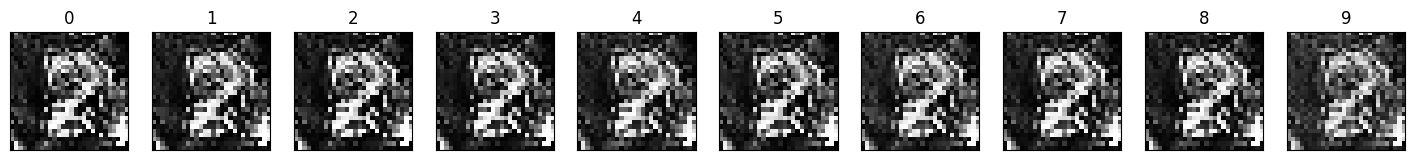

ÉPOCA 002 finalizada: Loss discriminador 2.713254 - Loss gerador 13.204541      


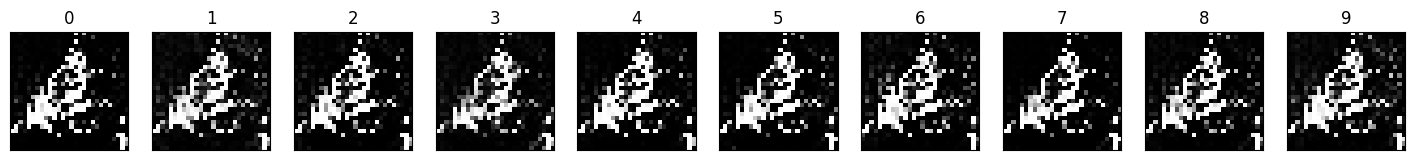

ÉPOCA 003 finalizada: Loss discriminador 2.700247 - Loss gerador 14.965186      


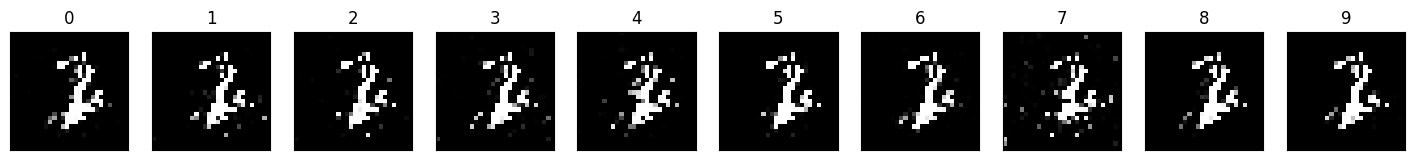

ÉPOCA 004 finalizada: Loss discriminador 2.704435 - Loss gerador 16.338725      


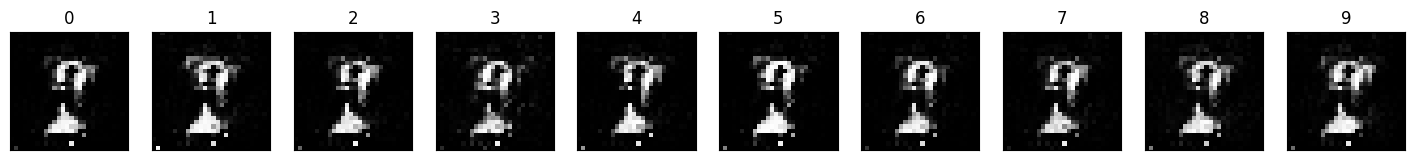

ÉPOCA 005 finalizada: Loss discriminador 2.686315 - Loss gerador 14.082983      


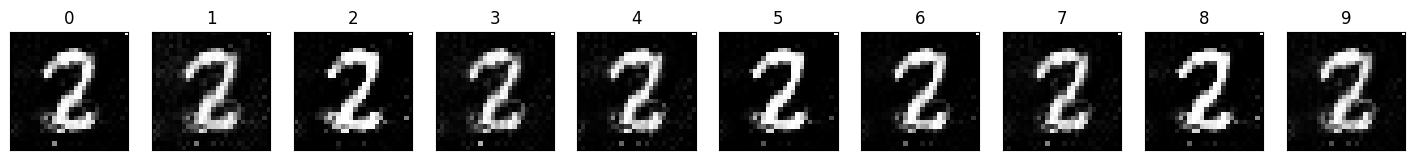

ÉPOCA 006 finalizada: Loss discriminador 2.690734 - Loss gerador 16.326702      


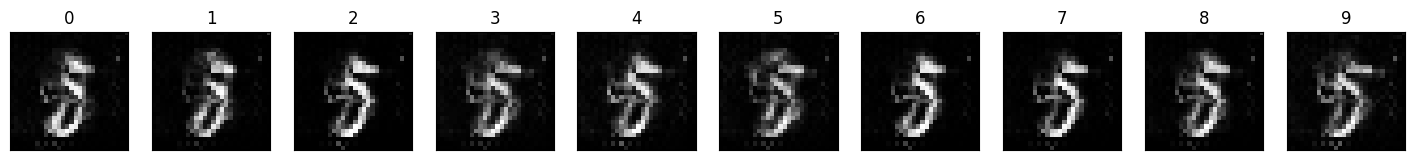

ÉPOCA 007 finalizada: Loss discriminador 2.682064 - Loss gerador 15.208621      


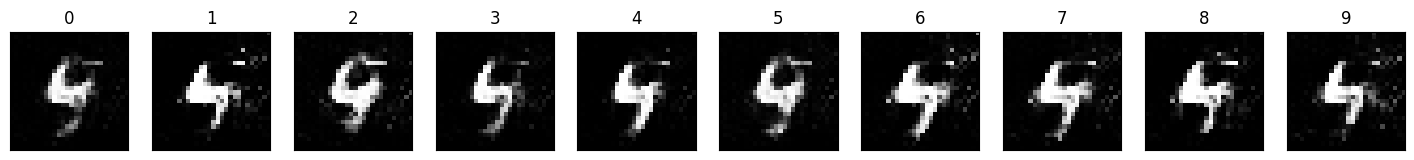

ÉPOCA 008 finalizada: Loss discriminador 2.684283 - Loss gerador 16.443005      


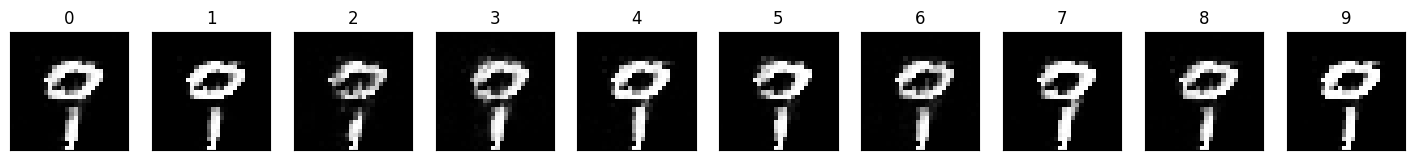

ÉPOCA 009 finalizada: Loss discriminador 2.674497 - Loss gerador 16.348505      


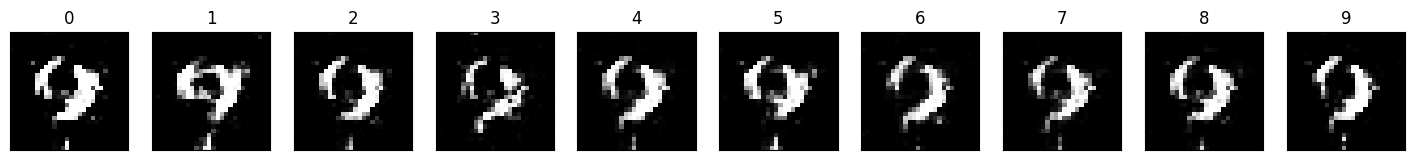

ÉPOCA 010 finalizada: Loss discriminador 2.682972 - Loss gerador 16.639432      


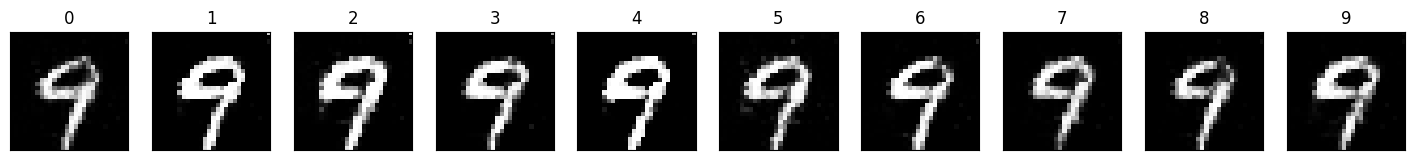

ÉPOCA 011 finalizada: Loss discriminador 2.673185 - Loss gerador 16.392321      


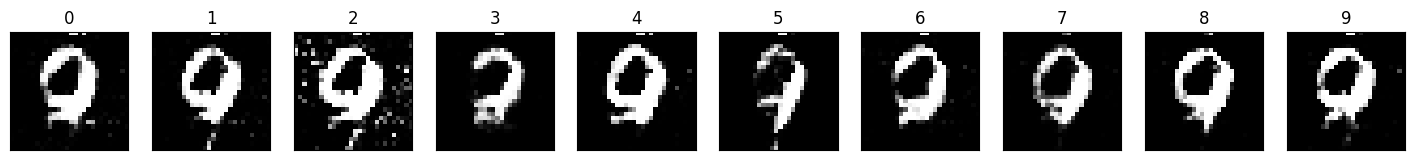

ÉPOCA 012 finalizada: Loss discriminador 2.677714 - Loss gerador 15.328599      


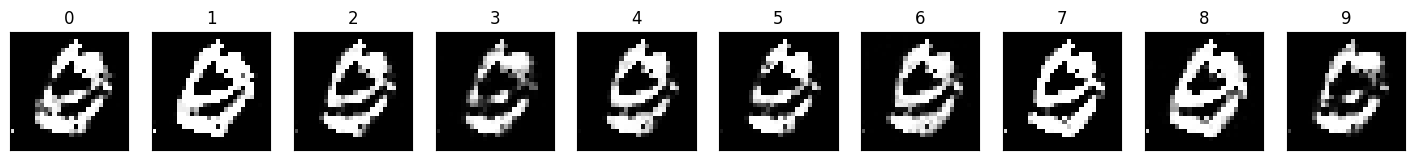

ÉPOCA 013 finalizada: Loss discriminador 2.689888 - Loss gerador 16.631546      


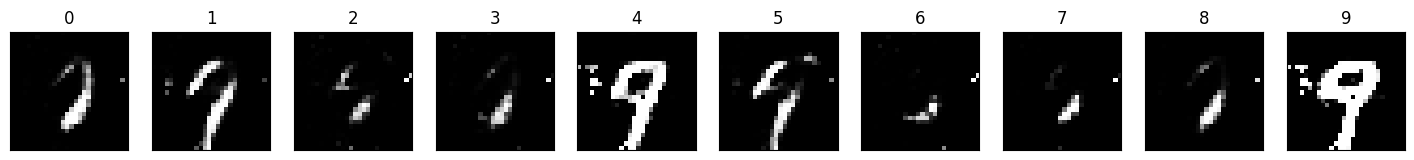

ÉPOCA 014 finalizada: Loss discriminador 2.687817 - Loss gerador 15.138294      


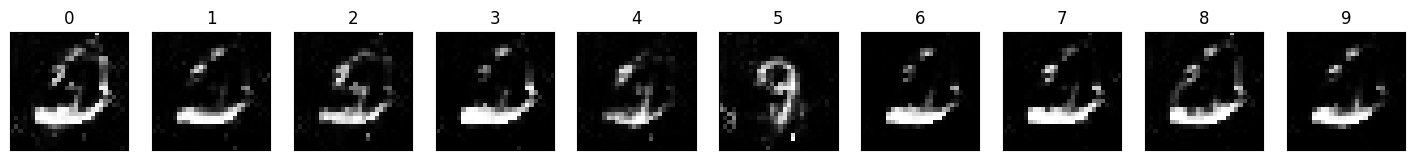

ÉPOCA 015 finalizada: Loss discriminador 2.680606 - Loss gerador 14.898545      


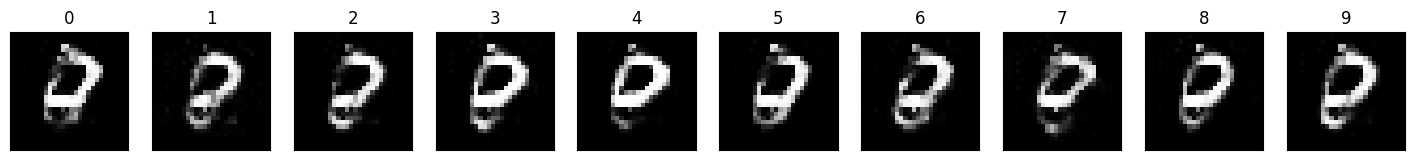

ÉPOCA 016 finalizada: Loss discriminador 2.674351 - Loss gerador 14.967183      


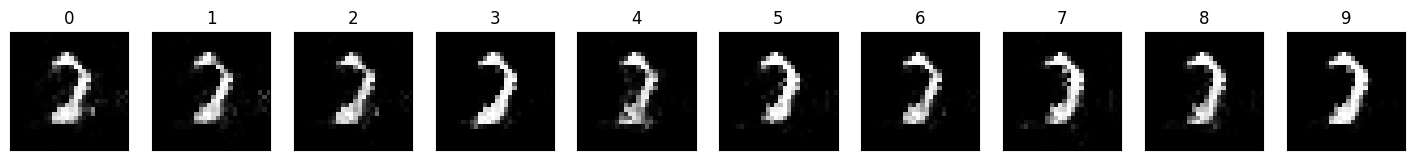

ÉPOCA 017 finalizada: Loss discriminador 2.657514 - Loss gerador 13.723543      


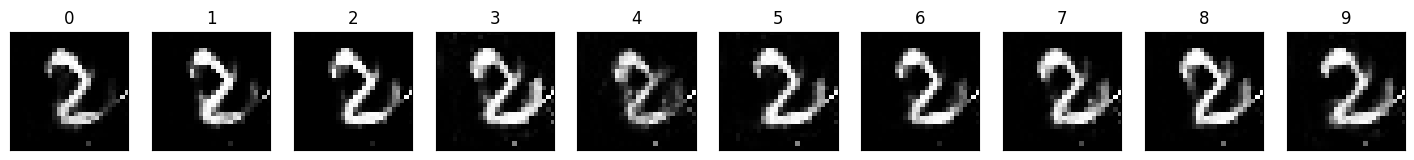

ÉPOCA 018 finalizada: Loss discriminador 2.655021 - Loss gerador 13.674547      


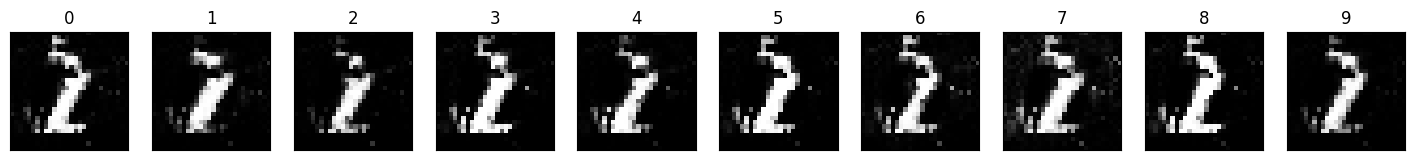

ÉPOCA 019 finalizada: Loss discriminador 2.650147 - Loss gerador 13.896096      


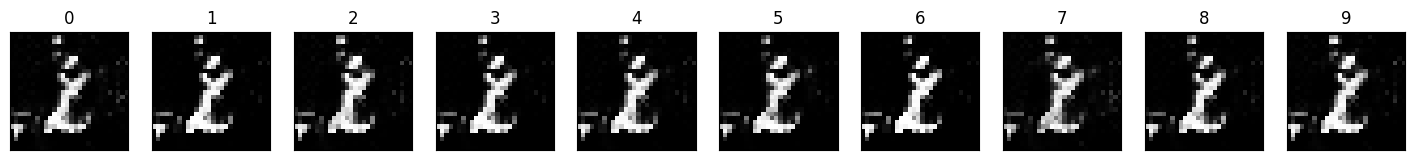

ÉPOCA 020 finalizada: Loss discriminador 2.655888 - Loss gerador 14.533265      


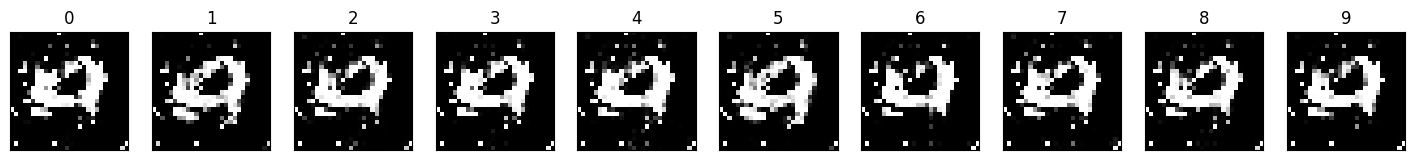

ÉPOCA 021 finalizada: Loss discriminador 2.659361 - Loss gerador 15.923149      


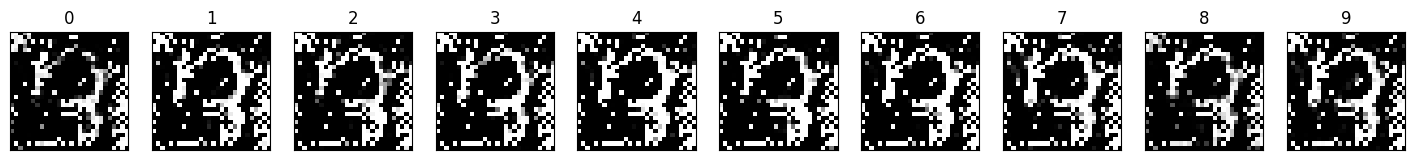

ÉPOCA 022 finalizada: Loss discriminador 2.648152 - Loss gerador 14.865662      


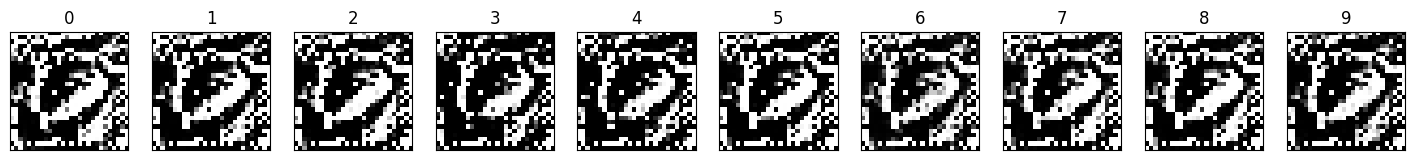

ÉPOCA 023 finalizada: Loss discriminador 2.644991 - Loss gerador 14.361559      


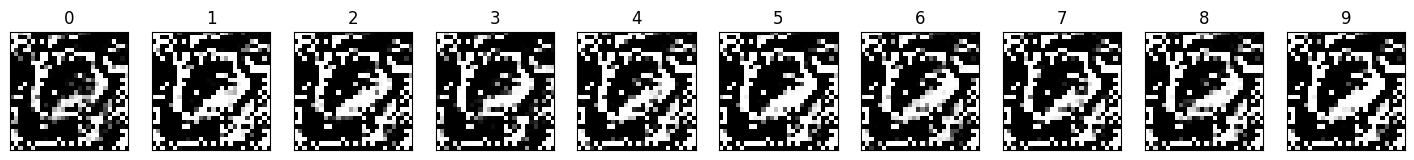

ÉPOCA 024 finalizada: Loss discriminador 2.642908 - Loss gerador 13.888441      


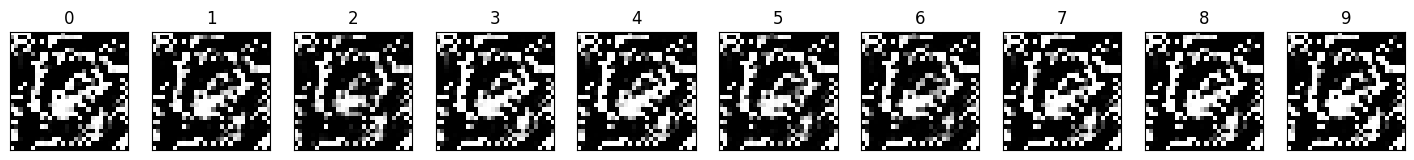

ÉPOCA 025 finalizada: Loss discriminador 2.653476 - Loss gerador 14.519680      


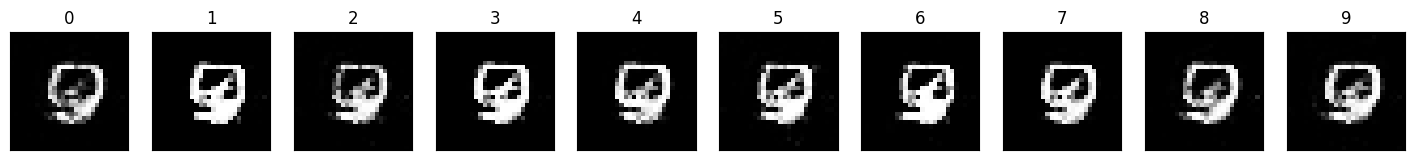

ÉPOCA 026 finalizada: Loss discriminador 2.666150 - Loss gerador 15.539774      


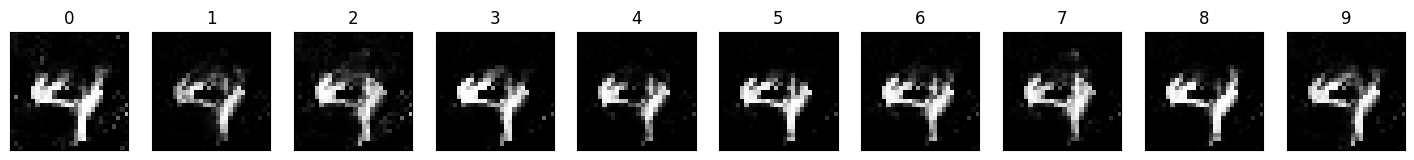

ÉPOCA 027 finalizada: Loss discriminador 2.675943 - Loss gerador 15.821242      


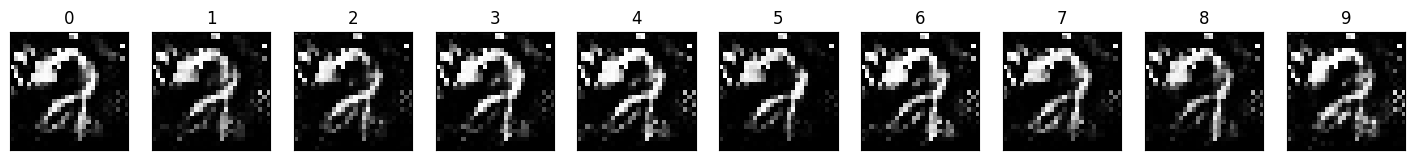

ÉPOCA 028 finalizada: Loss discriminador 2.653446 - Loss gerador 15.351318      


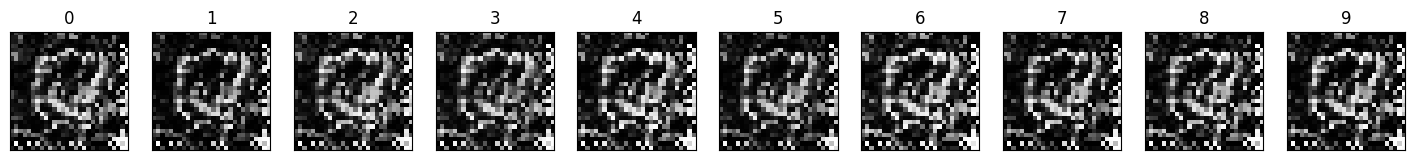

ÉPOCA 029 finalizada: Loss discriminador 2.667301 - Loss gerador 16.135769      


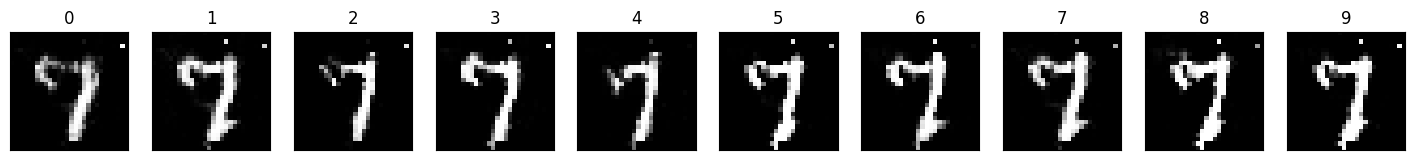

ÉPOCA 030 finalizada: Loss discriminador 2.674323 - Loss gerador 16.954647      


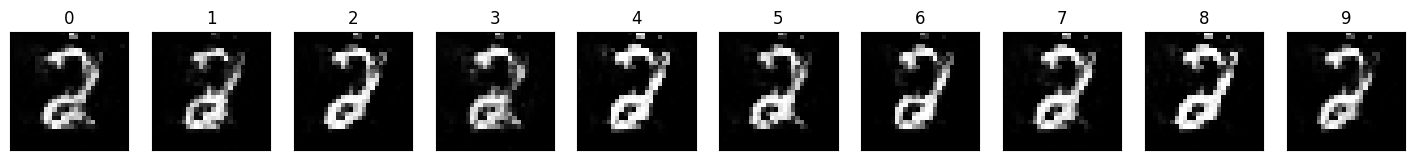

ÉPOCA 031 finalizada: Loss discriminador 2.666052 - Loss gerador 16.220513      


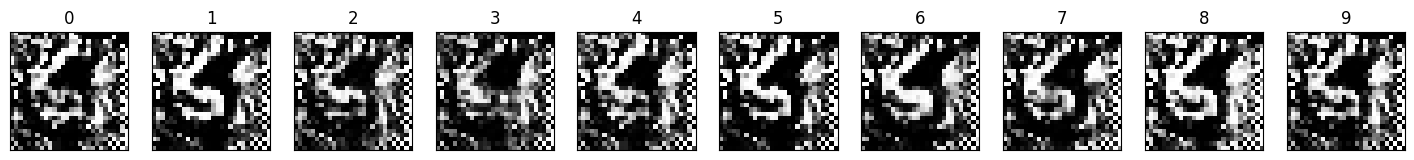

ÉPOCA 032 finalizada: Loss discriminador 2.659000 - Loss gerador 16.095193      


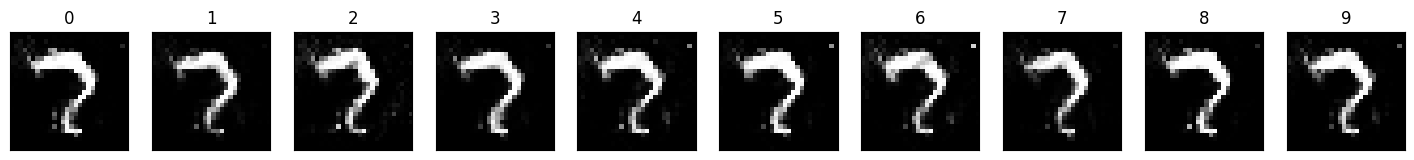

ÉPOCA 033 finalizada: Loss discriminador 2.668105 - Loss gerador 16.514332      


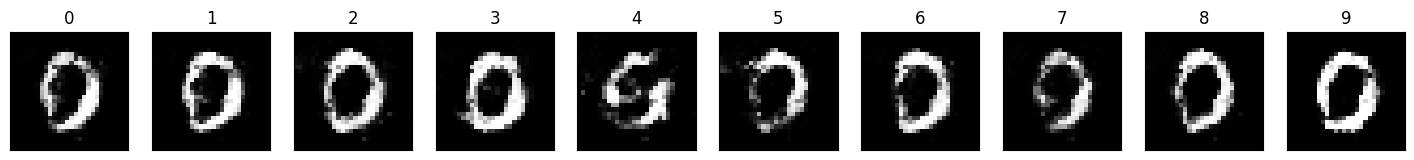

ÉPOCA 034 finalizada: Loss discriminador 2.668369 - Loss gerador 15.492549      


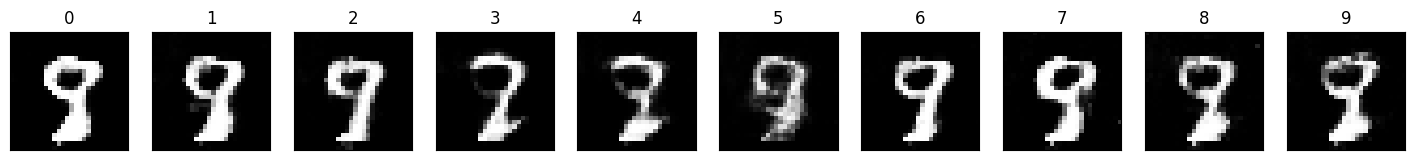

ÉPOCA 035 finalizada: Loss discriminador 2.676527 - Loss gerador 14.621620      


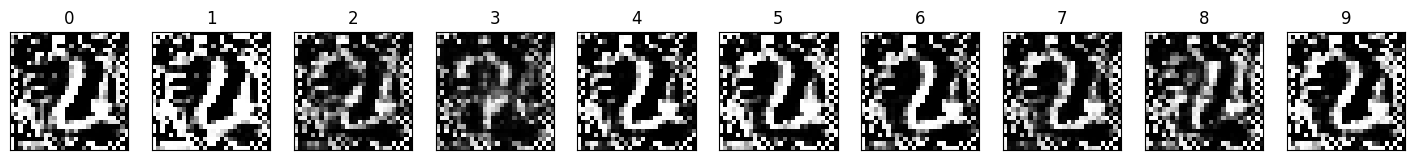

ÉPOCA 036 finalizada: Loss discriminador 2.645774 - Loss gerador 14.510818      


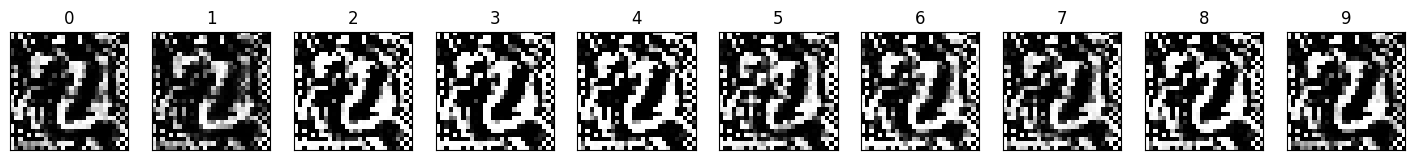

ÉPOCA 037 finalizada: Loss discriminador 2.640171 - Loss gerador 14.407544      


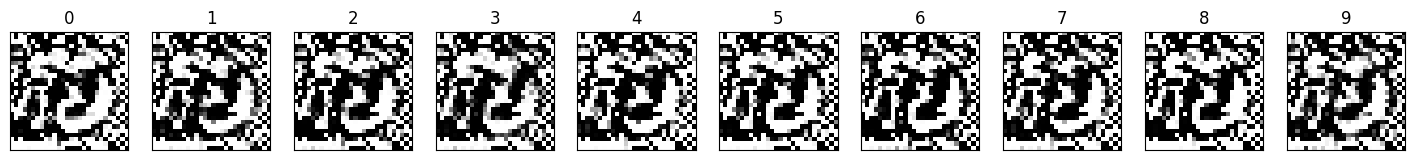

ÉPOCA 038 finalizada: Loss discriminador 2.641171 - Loss gerador 14.600359      


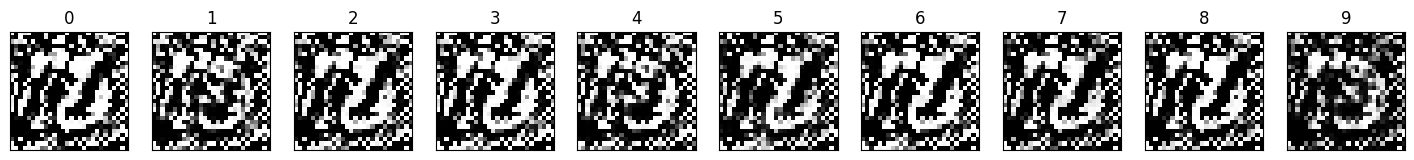

ÉPOCA 039 finalizada: Loss discriminador 2.646251 - Loss gerador 15.332935      


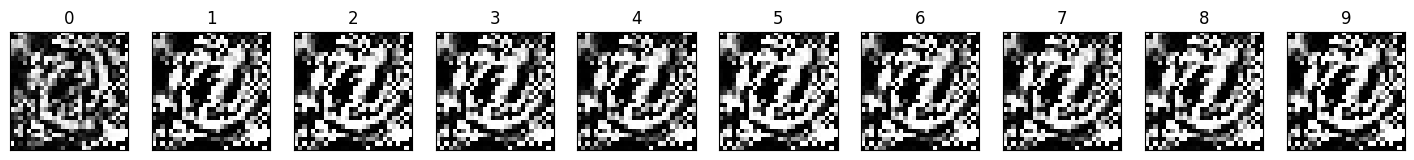

ÉPOCA 040 finalizada: Loss discriminador 2.645640 - Loss gerador 15.704716      


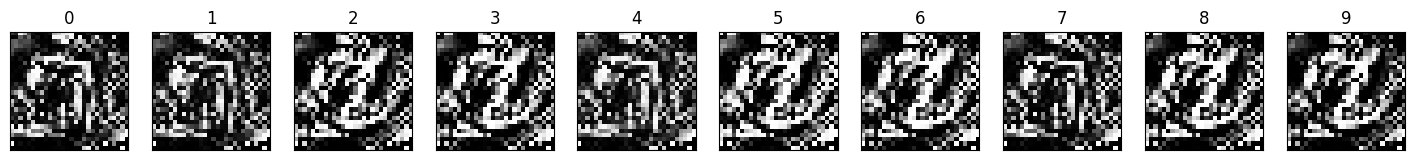

ÉPOCA 041 finalizada: Loss discriminador 2.640497 - Loss gerador 15.412224      


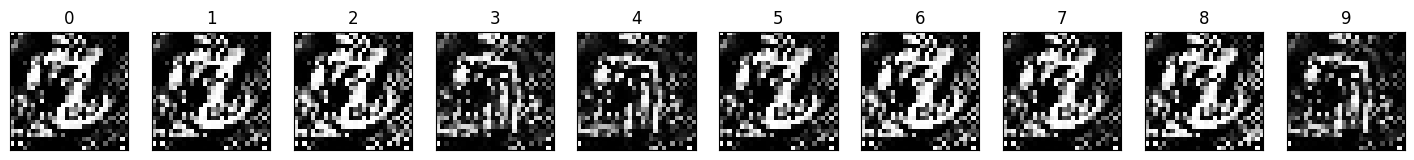

ÉPOCA 042 finalizada: Loss discriminador 2.666853 - Loss gerador 16.361882      


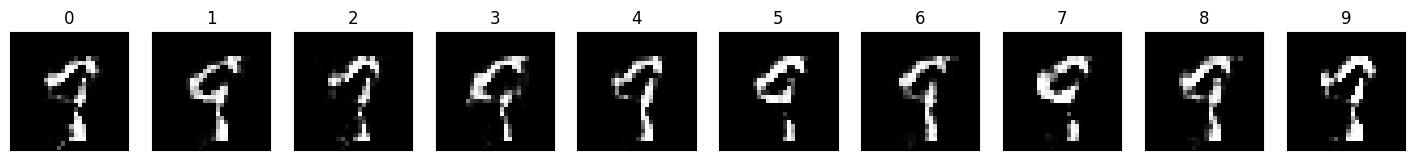

ÉPOCA 043 finalizada: Loss discriminador 2.666778 - Loss gerador 16.662182      


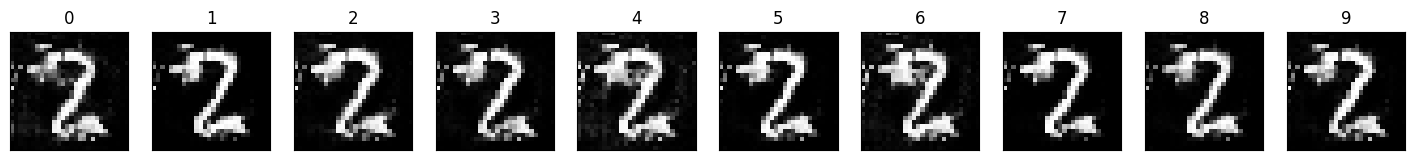

ÉPOCA 044 finalizada: Loss discriminador 2.646372 - Loss gerador 16.519103      


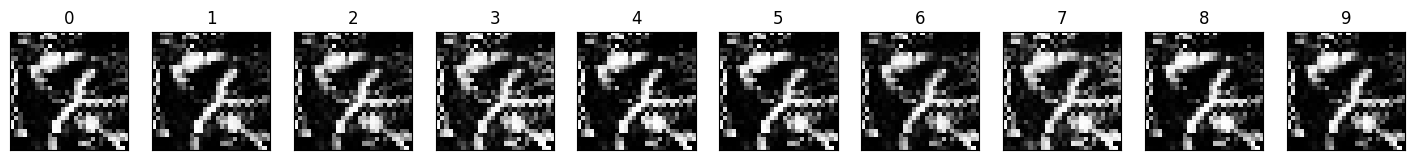

ÉPOCA 045 finalizada: Loss discriminador 2.638520 - Loss gerador 15.191128      


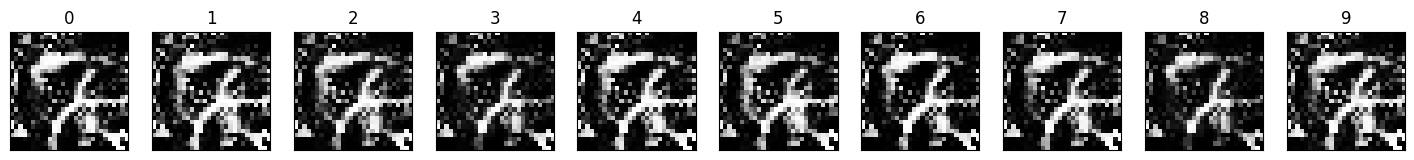

ÉPOCA 046 finalizada: Loss discriminador 2.637390 - Loss gerador 15.010341      


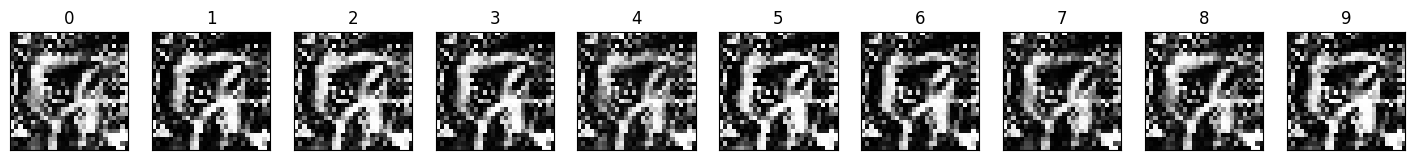

ÉPOCA 047 finalizada: Loss discriminador 2.639901 - Loss gerador 14.911562      


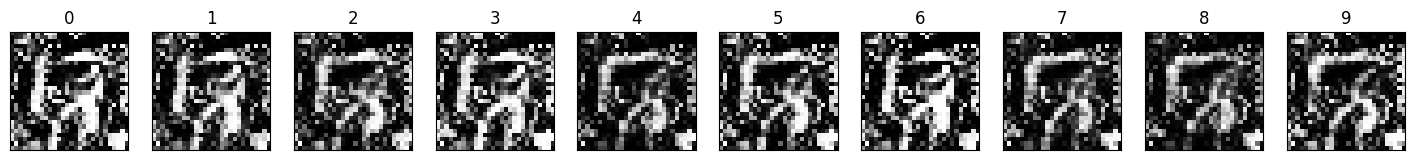

ÉPOCA 048 finalizada: Loss discriminador 2.643864 - Loss gerador 17.024004      


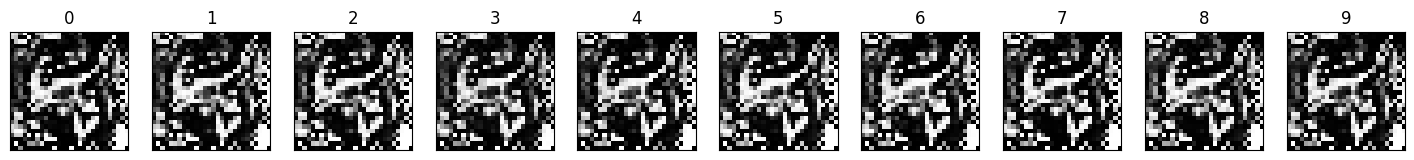

ÉPOCA 049 finalizada: Loss discriminador 2.639478 - Loss gerador 16.714092      


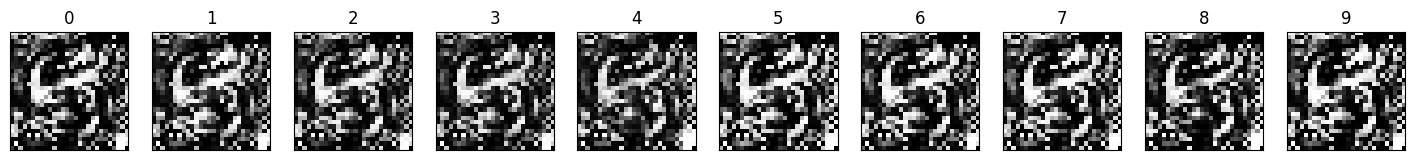

ÉPOCA 050 finalizada: Loss discriminador 2.641899 - Loss gerador 16.194005      
Novo melhor G salvo em época 50 com loss 16.194005
Novo melhor D salvo em época 50 com loss 2.641899


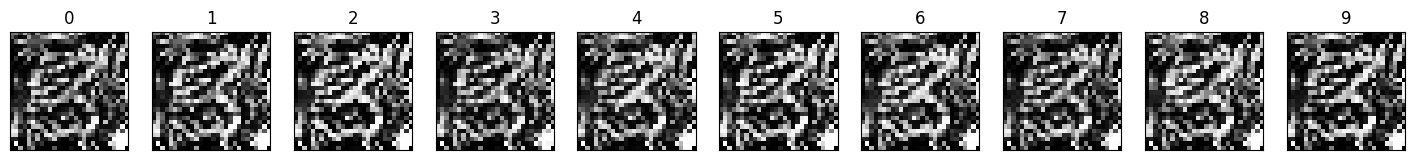

ÉPOCA 051 finalizada: Loss discriminador 2.638637 - Loss gerador 16.075638      
Novo melhor G salvo em época 51 com loss 16.075638
Novo melhor D salvo em época 51 com loss 2.638637


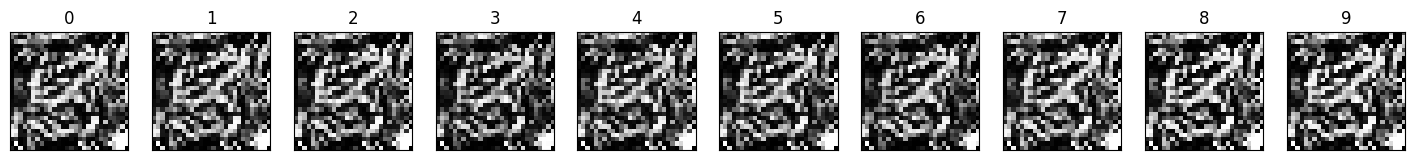

ÉPOCA 052 finalizada: Loss discriminador 2.638045 - Loss gerador 15.572761      
Novo melhor G salvo em época 52 com loss 15.572761
Novo melhor D salvo em época 52 com loss 2.638045


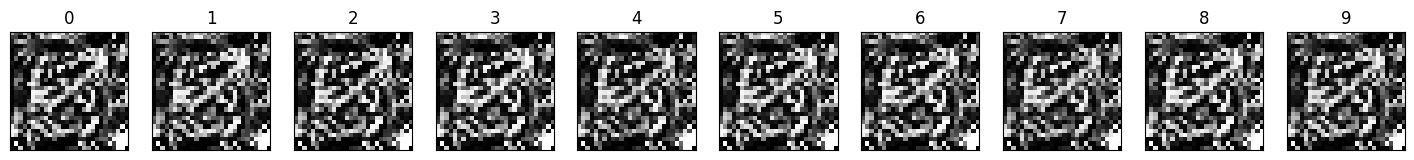

ÉPOCA 053 finalizada: Loss discriminador 2.639700 - Loss gerador 15.804518      


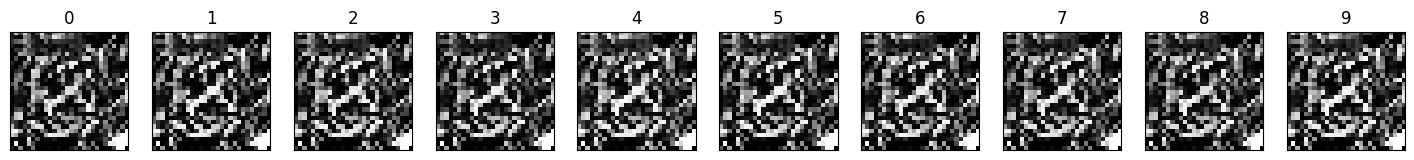

ÉPOCA 054 finalizada: Loss discriminador 2.638207 - Loss gerador 16.427848      


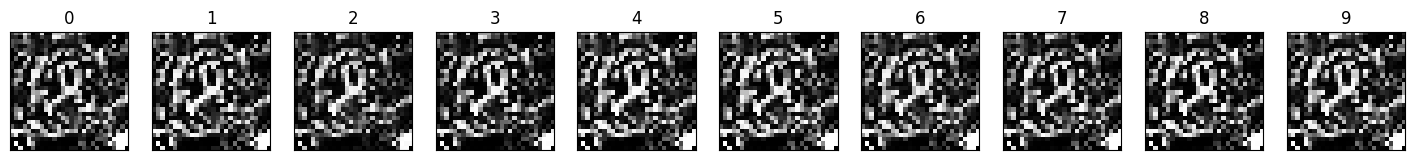

ÉPOCA 055 finalizada: Loss discriminador 2.639020 - Loss gerador 16.385098      


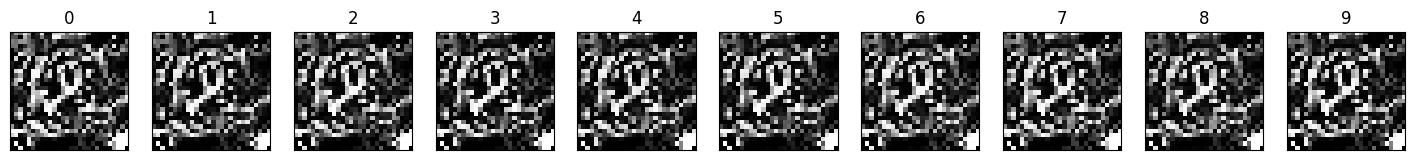

ÉPOCA 056 finalizada: Loss discriminador 2.635363 - Loss gerador 15.422397      
Novo melhor G salvo em época 56 com loss 15.422397
Novo melhor D salvo em época 56 com loss 2.635363


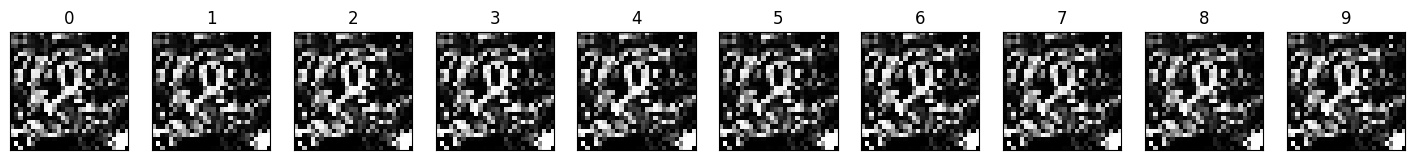

ÉPOCA 057 finalizada: Loss discriminador 2.638706 - Loss gerador 15.166082      
Novo melhor G salvo em época 57 com loss 15.166082


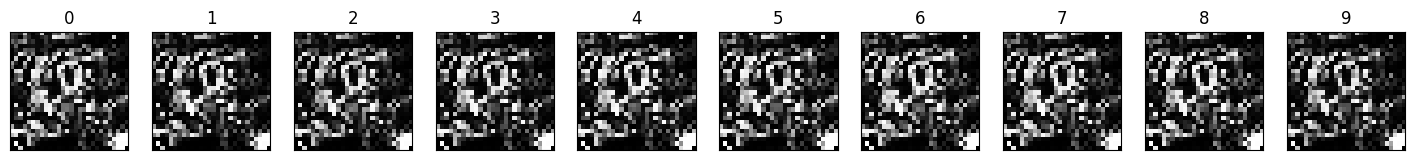

ÉPOCA 058 finalizada: Loss discriminador 2.636389 - Loss gerador 15.279133      


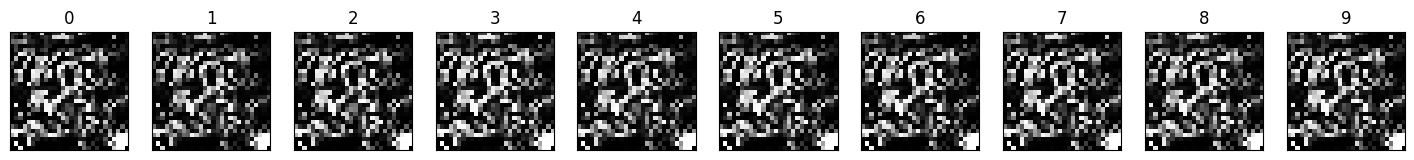

ÉPOCA 059 finalizada: Loss discriminador 2.635950 - Loss gerador 14.834405      
Novo melhor G salvo em época 59 com loss 14.834405


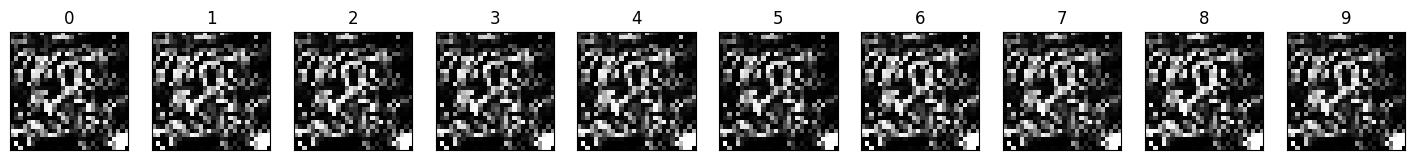

ÉPOCA 060 finalizada: Loss discriminador 2.637721 - Loss gerador 14.768534      
Novo melhor G salvo em época 60 com loss 14.768534


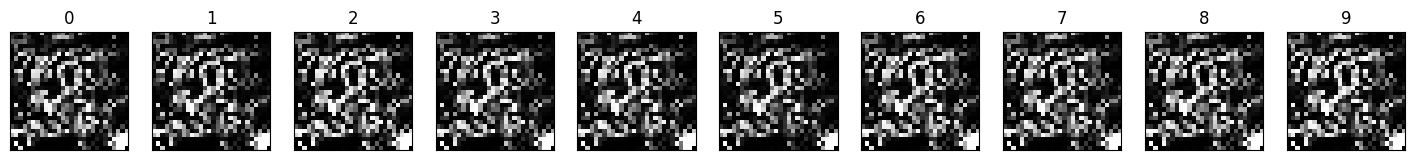

ÉPOCA 061 finalizada: Loss discriminador 2.635589 - Loss gerador 14.879181      


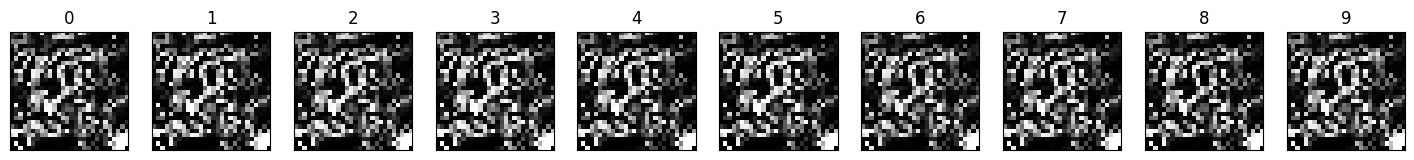

ÉPOCA 062 finalizada: Loss discriminador 2.636271 - Loss gerador 15.841629      


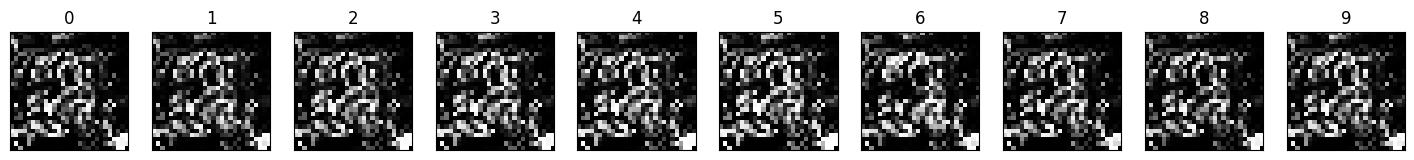

ÉPOCA 063 finalizada: Loss discriminador 2.636979 - Loss gerador 15.928716      


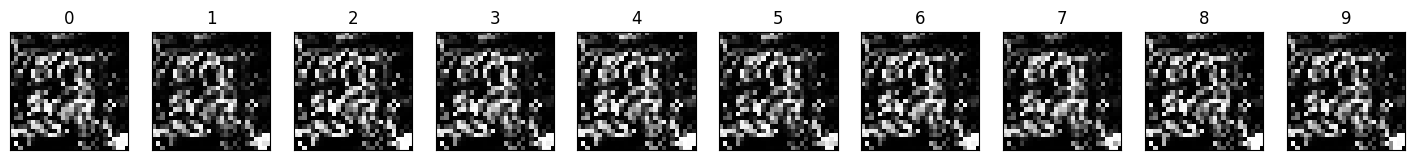

ÉPOCA 064 finalizada: Loss discriminador 2.650136 - Loss gerador 20.154839      


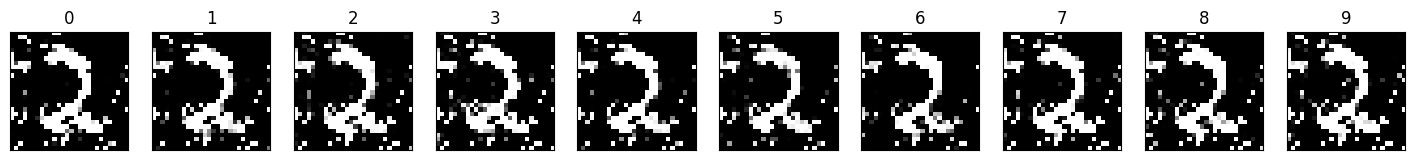

ÉPOCA 065 finalizada: Loss discriminador 2.639610 - Loss gerador 21.539495      


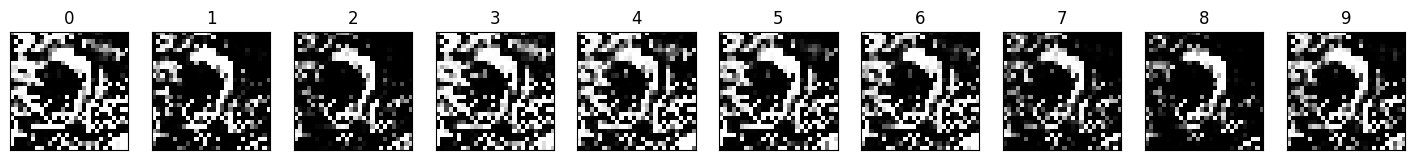

ÉPOCA 066 finalizada: Loss discriminador 2.638496 - Loss gerador 20.793777      


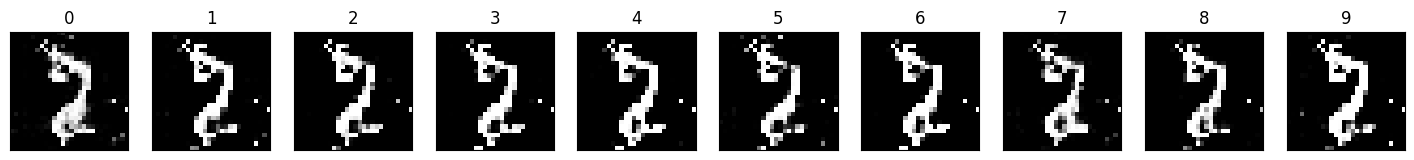

ÉPOCA 067 finalizada: Loss discriminador 2.667904 - Loss gerador 23.556181      


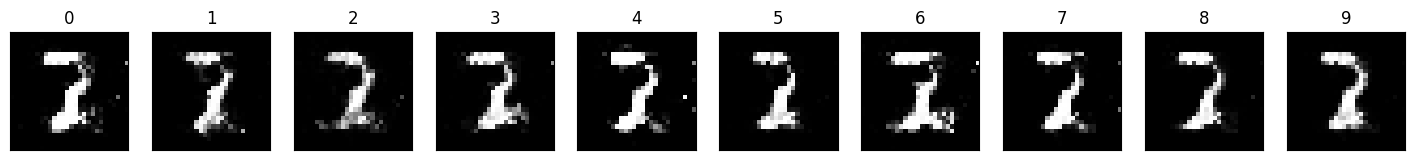

ÉPOCA 068 finalizada: Loss discriminador 2.661655 - Loss gerador 21.343623      


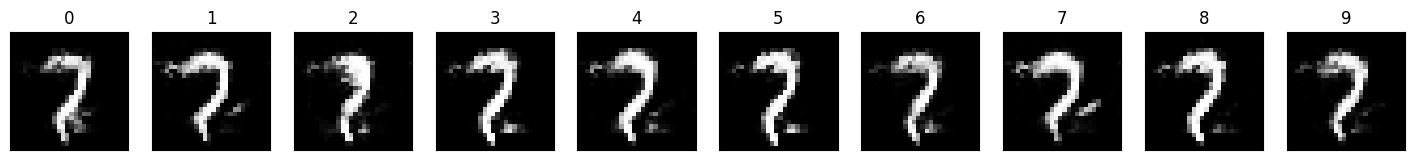

ÉPOCA 069 finalizada: Loss discriminador 2.673983 - Loss gerador 21.863150      


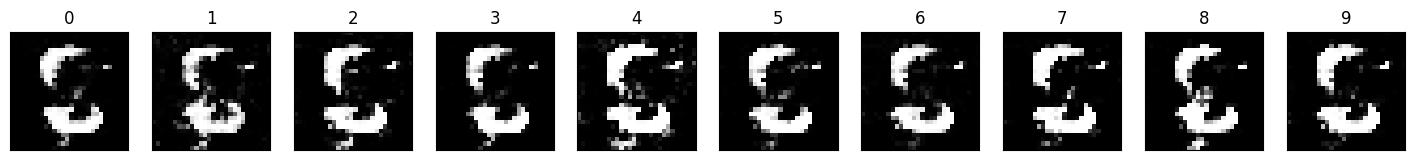

ÉPOCA 070 finalizada: Loss discriminador 2.649556 - Loss gerador 23.157576      


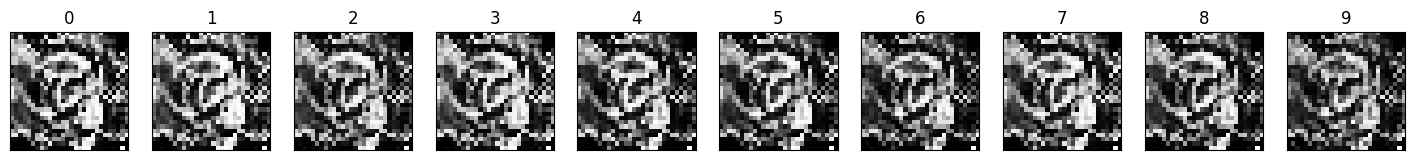

ÉPOCA 071 finalizada: Loss discriminador 2.653907 - Loss gerador 22.020165      


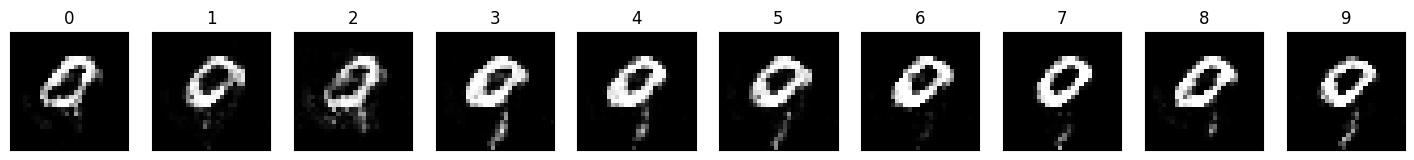

ÉPOCA 072 finalizada: Loss discriminador 2.662660 - Loss gerador 20.489313      


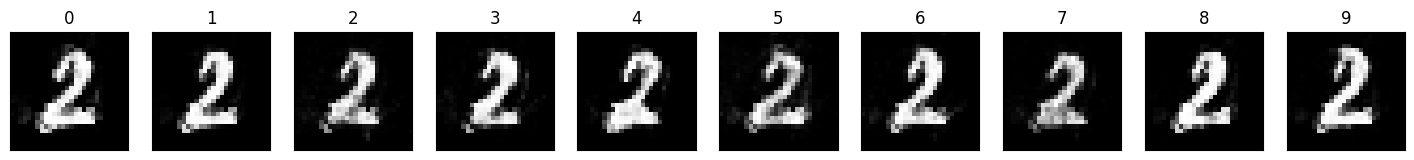

ÉPOCA 073 finalizada: Loss discriminador 2.664106 - Loss gerador 18.978728      


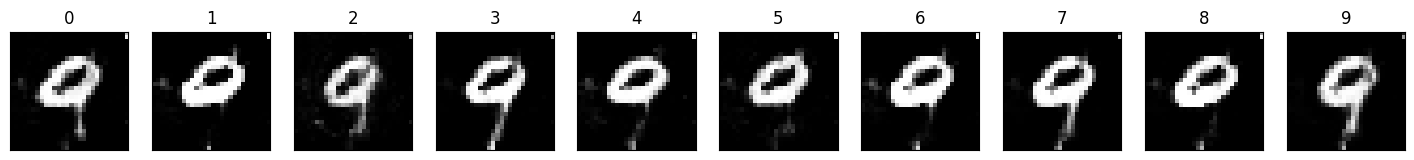

ÉPOCA 074 finalizada: Loss discriminador 2.655980 - Loss gerador 20.370760      


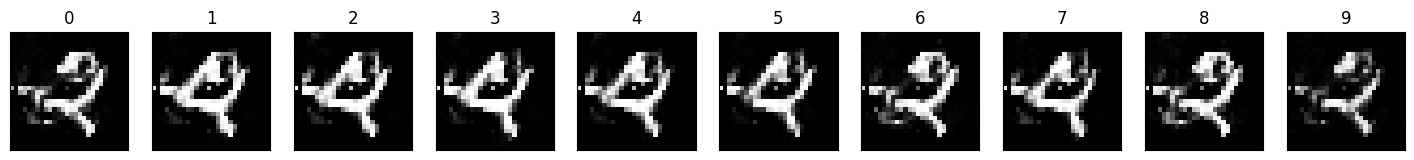

ÉPOCA 075 finalizada: Loss discriminador 2.669179 - Loss gerador 18.726551      


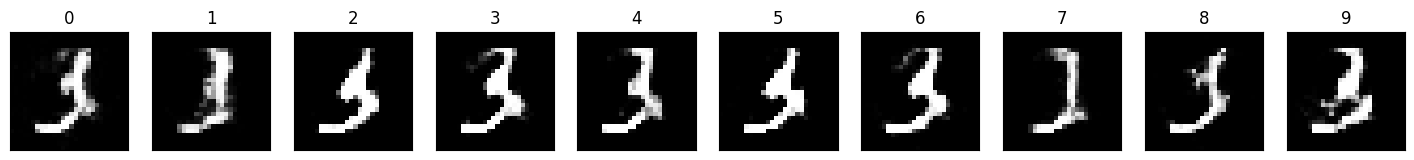

ÉPOCA 076 finalizada: Loss discriminador 2.666060 - Loss gerador 19.394893      


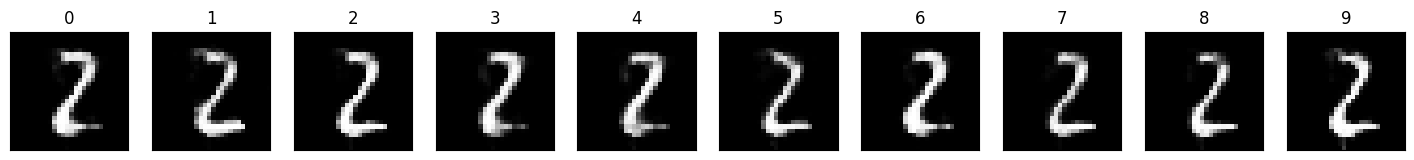

ÉPOCA 077 finalizada: Loss discriminador 2.673303 - Loss gerador 18.791283      


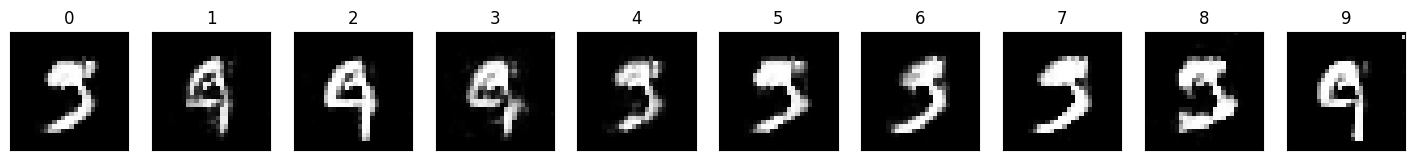

ÉPOCA 078 finalizada: Loss discriminador 2.689831 - Loss gerador 18.061997      


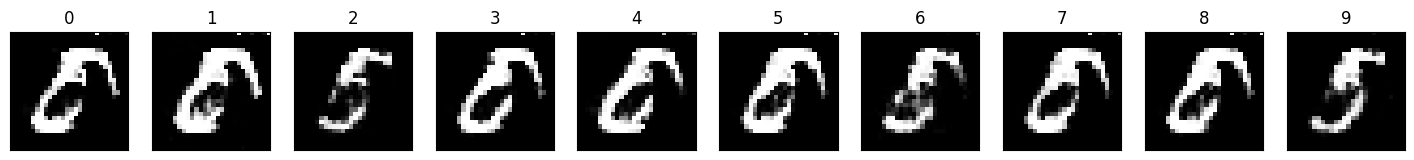

ÉPOCA 079 finalizada: Loss discriminador 2.671206 - Loss gerador 17.225710      


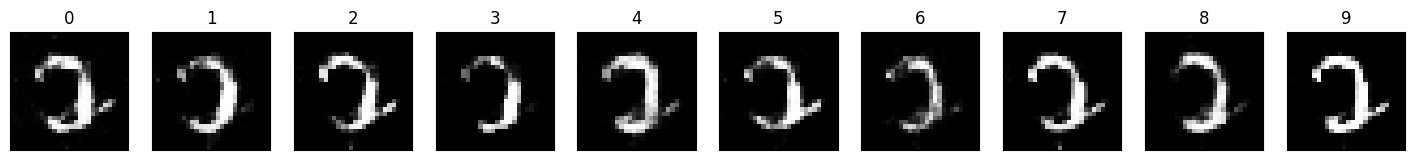

ÉPOCA 080 finalizada: Loss discriminador 2.653357 - Loss gerador 18.107581      


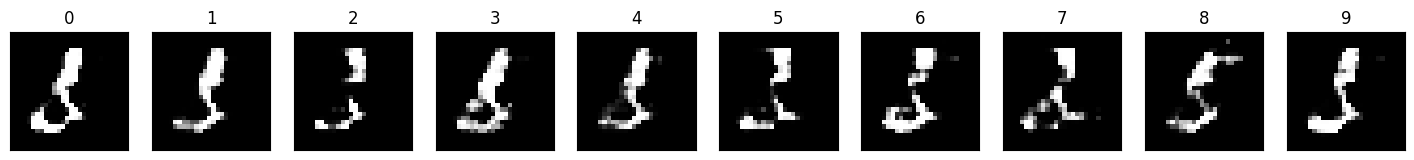

ÉPOCA 081 finalizada: Loss discriminador 2.664611 - Loss gerador 17.352157      


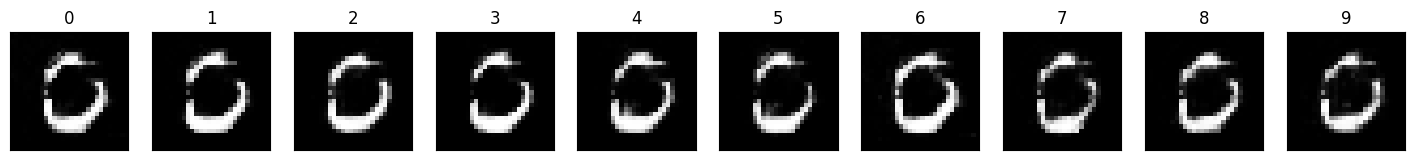

ÉPOCA 082 finalizada: Loss discriminador 2.680417 - Loss gerador 18.140163      


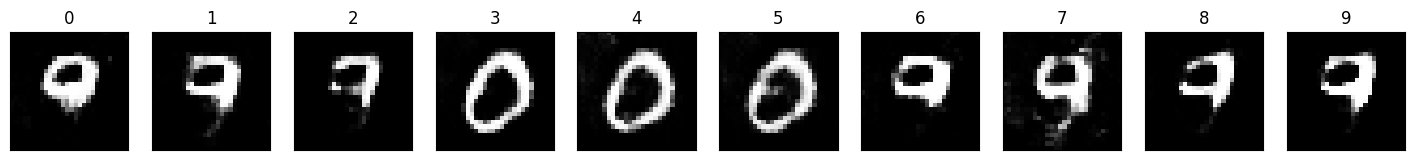

ÉPOCA 083 finalizada: Loss discriminador 2.689747 - Loss gerador 15.798627      


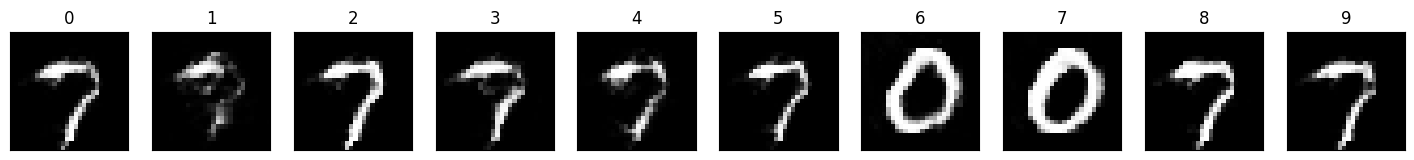

ÉPOCA 084 finalizada: Loss discriminador 2.700314 - Loss gerador 14.403841      
Novo melhor G salvo em época 84 com loss 14.403841


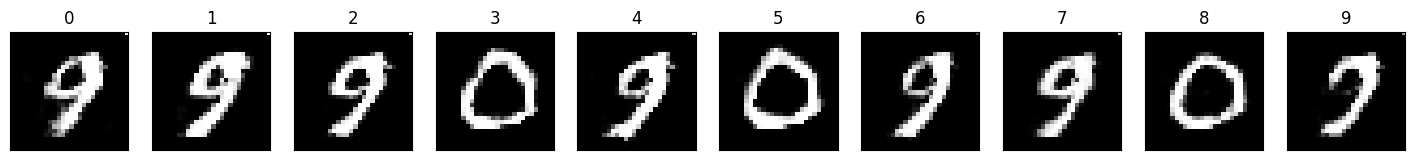

ÉPOCA 085 finalizada: Loss discriminador 2.722590 - Loss gerador 13.882749      
Novo melhor G salvo em época 85 com loss 13.882749


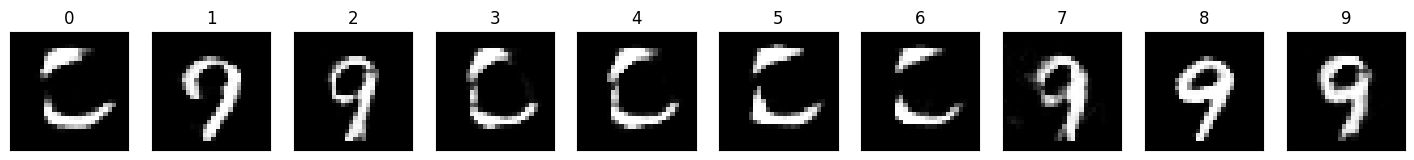

ÉPOCA 086 finalizada: Loss discriminador 2.703861 - Loss gerador 12.977202      
Novo melhor G salvo em época 86 com loss 12.977202


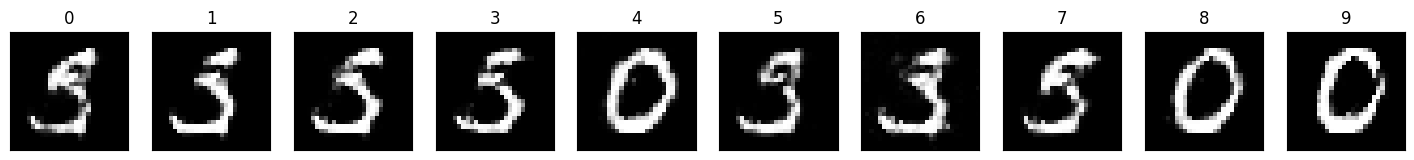

ÉPOCA 087 finalizada: Loss discriminador 2.696876 - Loss gerador 13.434394      


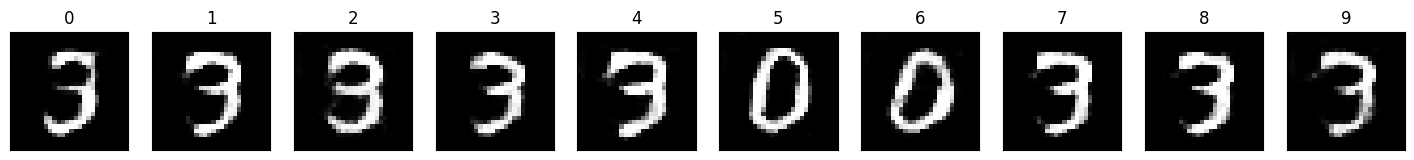

ÉPOCA 088 finalizada: Loss discriminador 2.688770 - Loss gerador 14.367370      


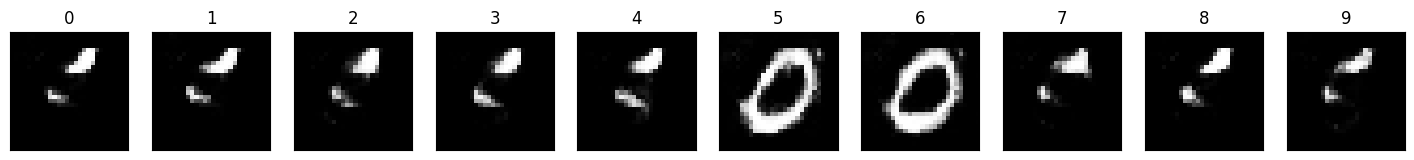

ÉPOCA 089 finalizada: Loss discriminador 2.705045 - Loss gerador 14.294406      


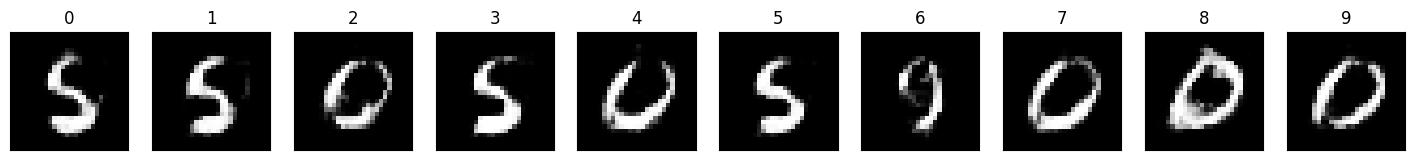

ÉPOCA 090 finalizada: Loss discriminador 2.674478 - Loss gerador 14.198063      


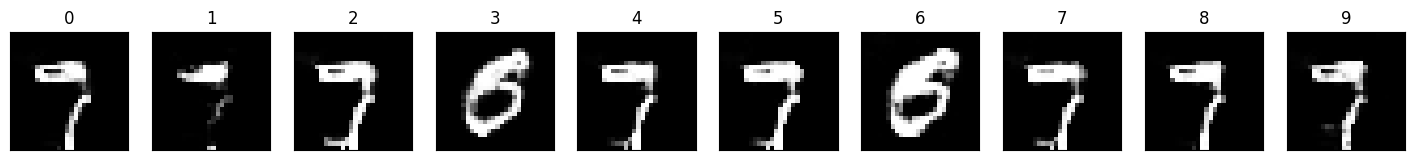

ÉPOCA 091 finalizada: Loss discriminador 2.691650 - Loss gerador 14.543405      


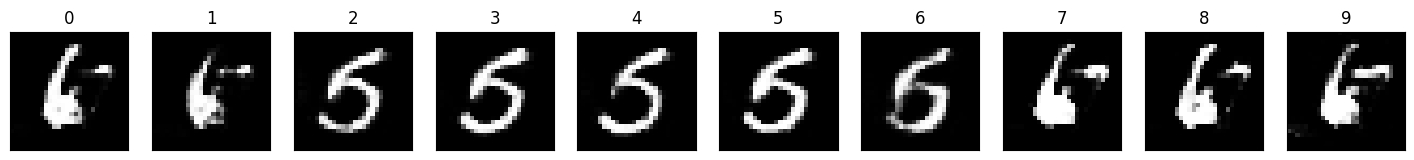

ÉPOCA 092 finalizada: Loss discriminador 2.697730 - Loss gerador 15.020382      


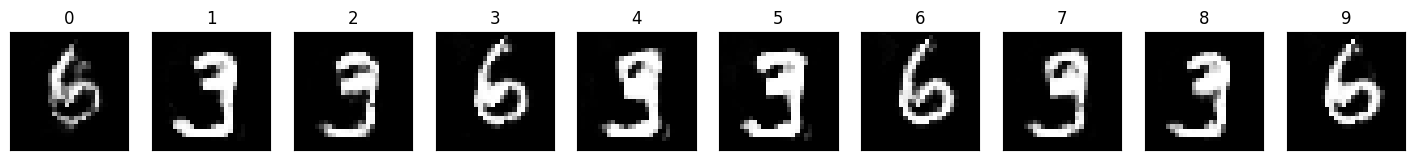

ÉPOCA 093 finalizada: Loss discriminador 2.690712 - Loss gerador 14.031056      


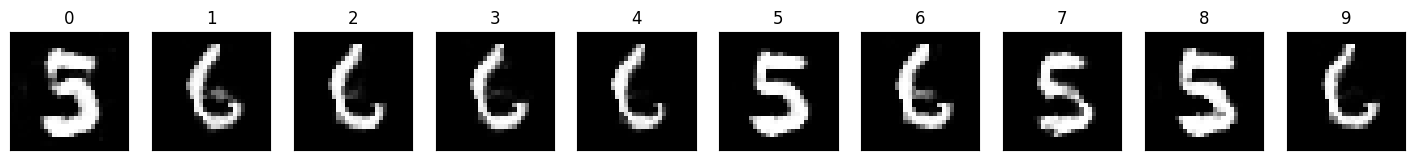

ÉPOCA 094 finalizada: Loss discriminador 2.676924 - Loss gerador 14.819480      


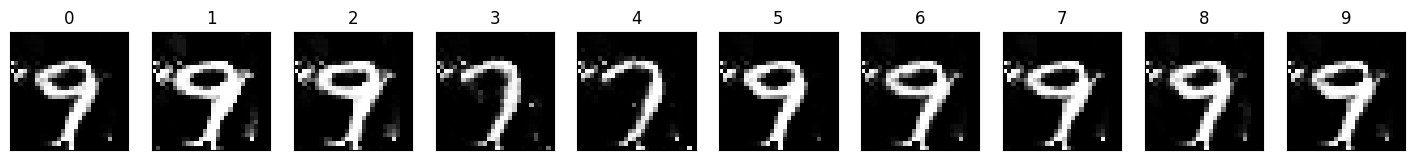

ÉPOCA 095 finalizada: Loss discriminador 2.686639 - Loss gerador 16.596653      


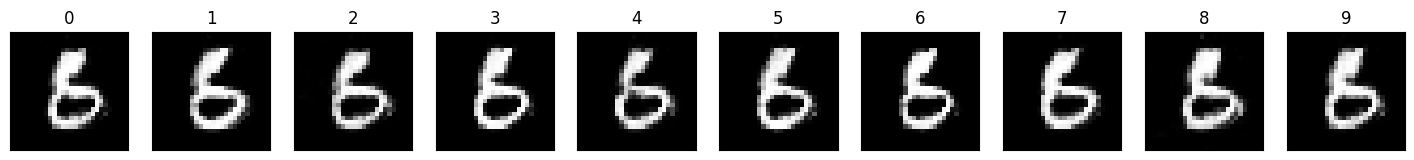

ÉPOCA 096 finalizada: Loss discriminador 2.666993 - Loss gerador 16.930675      


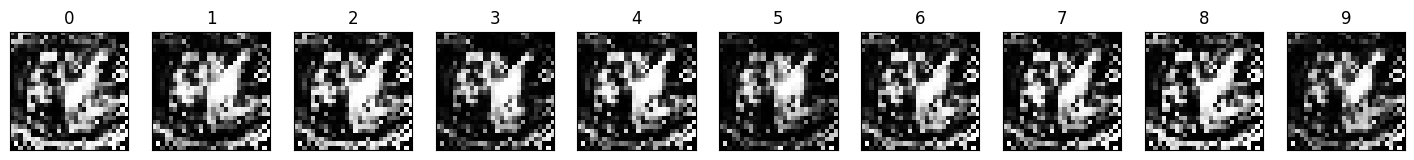

ÉPOCA 097 finalizada: Loss discriminador 2.674533 - Loss gerador 16.801290      


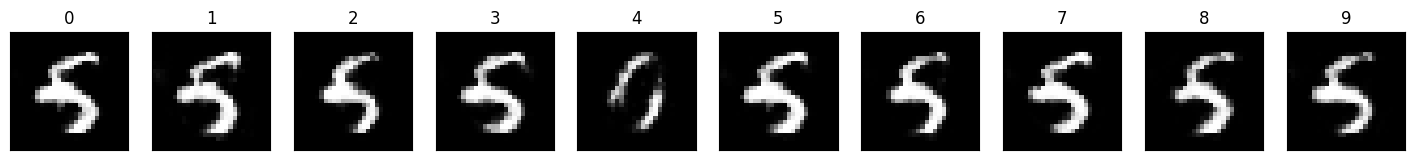

ÉPOCA 098 finalizada: Loss discriminador 2.671386 - Loss gerador 16.524414      


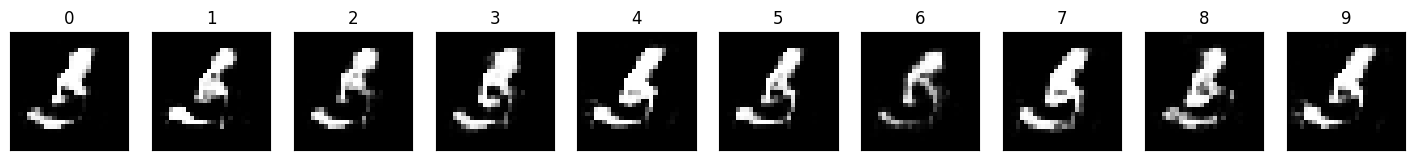

ÉPOCA 099 finalizada: Loss discriminador 2.662605 - Loss gerador 17.411163      


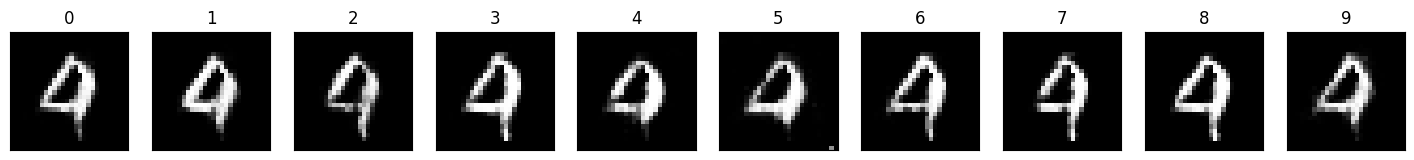

ÉPOCA 100 finalizada: Loss discriminador 2.651252 - Loss gerador 17.016074      


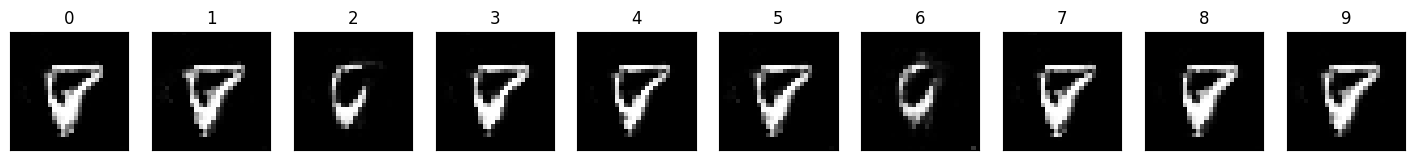

Melhor G carregado (época 86, loss 12.977202)
Melhor D carregado (época 56, loss 2.635363)


In [7]:
best_g_loss = float('inf')
best_d_loss = float('inf')
best_g_path = 'best_G.pt'
best_d_path = 'best_D.pt'

for epoch in range(100):
    D_running_loss = 0
    G_running_loss = 0

    for i, (imagens_reais, labels_reais_digit) in enumerate(loader):
        batch_size = imagens_reais.size(0)

        # Imagens antes dessa transformação ficam entre 0 e 1.
        # Após a transformação, 1 continua sendo 1, e 0 vira -1.
        imagens_reais = imagens_reais * 2 - 1
        imagens_reais = imagens_reais.to(device)
        labels_reais_digit = labels_reais_digit.to(device)

        # =========================================================
        # Treinamento do discriminador (ACGAN)
        # =========================================================
        DOptimizer.zero_grad()

        # (1) Reais: D deve dizer real e a classe correta
        outputs_reais_adv, outputs_reais_cls = D.forward(imagens_reais)

        labels_reais_adv = (torch.ones(batch_size) * 0.9).to(device)  # suavização
        D_loss_reais_adv = criterion_adv(outputs_reais_adv.view(-1), labels_reais_adv)

        D_loss_reais_cls = criterion_cls(outputs_reais_cls, labels_reais_digit)

        # (2) Falsas: G gera condicionando na classe y_fake
        ruido = np.random.uniform(-1.0, 1.0, (batch_size, 100))
        ruido = torch.from_numpy(ruido).float().to(device)

        # Escolhe labels desejados aleatoriamente para o batch
        labels_fake_digit = torch.randint(0, 10, (batch_size,), device=device)

        imagens_falsas = G.forward(ruido, labels_fake_digit).detach()
        outputs_falsas_adv, outputs_falsas_cls = D.forward(imagens_falsas)

        labels_falsas_adv = torch.zeros(batch_size).to(device)
        D_loss_falsas_adv = criterion_adv(outputs_falsas_adv.view(-1), labels_falsas_adv)

        # Em ACGAN, normalmente também treinamos o classificador do D nas fakes com o label-condição
        D_loss_falsas_cls = criterion_cls(outputs_falsas_cls, labels_fake_digit)

        D_loss = (D_loss_reais_adv + D_loss_falsas_adv) + (D_loss_reais_cls + D_loss_falsas_cls)
        D_loss.backward()
        DOptimizer.step()

        # =========================================================
        # Treinamento do gerador (ACGAN)
        # =========================================================
        GOptimizer.zero_grad()

        ruido = np.random.uniform(-1.0, 1.0, (batch_size, 100))
        ruido = torch.from_numpy(ruido).float().to(device)

        # Escolhe de novo labels desejados
        labels_fake_digit = torch.randint(0, 10, (batch_size,), device=device)

        imagens_falsas = G.forward(ruido, labels_fake_digit)
        outputs_falsas_adv, outputs_falsas_cls = D.forward(imagens_falsas)

        # Gerador quer que D diga "real"
        labels_reais_adv = torch.ones(batch_size).to(device)
        G_loss_adv = criterion_adv(outputs_falsas_adv.view(-1), labels_reais_adv)

        # E quer que D classifique como a classe desejada
        G_loss_cls = criterion_cls(outputs_falsas_cls, labels_fake_digit)

        # Peso das perdas (pode começar assim)
        lambda_cls = 1.0
        Gloss = G_loss_adv + lambda_cls * G_loss_cls

        Gloss.backward()
        GOptimizer.step()

        D_running_loss += D_loss.item()
        G_running_loss += Gloss.item()

        print('\rÉpoca {:03d} - Loop {:3d} de {:3d}: Loss discriminador {:03.5f} - custo gerador {:03.5f}'.format(
            epoch + 1, i + 1, len(loader), D_loss.item(), Gloss.item()
        ), end='\r')
    
    D_running_loss /= len(loader)
    G_running_loss /= len(loader)
    print('ÉPOCA {:03d} finalizada: Loss discriminador {:03.6f} - Loss gerador {:03.6f}      '.format(
        epoch + 1, D_running_loss, G_running_loss
    ))

    # Salva o melhor G (menor loss do gerador)
    if epoch >= 49:
        if G_running_loss < best_g_loss:
            best_g_loss = G_running_loss
            torch.save({
                'epoch': epoch + 1,
                'loss': best_g_loss,
                'model_state_dict': G.state_dict()
            }, best_g_path)
            print(f'Novo melhor G salvo em época {epoch + 1} com loss {best_g_loss:.6f}')

        # Salva o melhor D (menor loss do discriminador)
        if D_running_loss < best_d_loss:
            best_d_loss = D_running_loss
            torch.save({
                'epoch': epoch + 1,
                'loss': best_d_loss,
                'model_state_dict': D.state_dict()
            }, best_d_path)
            print(f'Novo melhor D salvo em época {epoch + 1} com loss {best_d_loss:.6f}')

    # Plotando 10 imagens: uma de cada número (0 a 9) por epoch
    fig, ax = plt.subplots(1, 10, figsize=(18,4))

    batch_plot = 10
    ruido_plot = np.random.uniform(-1.0, 1.0, (batch_plot, 100))
    ruido_plot = torch.from_numpy(ruido_plot).float().to(device)

    # 0,1,2,3,4,5,6,7,8,9
    labels_plot = torch.arange(0, 10, device=device, dtype=torch.long)

    imagens_plot = G.forward(ruido_plot, labels_plot)

    for j in range(10):
        ax[j].imshow(imagens_plot[j, 0].cpu().detach().numpy(), cmap='gray')
        ax[j].xaxis.set_visible(False)
        ax[j].yaxis.set_visible(False)
        ax[j].set_title(str(j))

    plt.show()

# Carrega os melhores modelos ao final do treinamento
checkpoint_g = torch.load(best_g_path, map_location=device)
checkpoint_d = torch.load(best_d_path, map_location=device)

G.load_state_dict(checkpoint_g['model_state_dict'])
D.load_state_dict(checkpoint_d['model_state_dict'])

print(f"Melhor G carregado (época {checkpoint_g['epoch']}, loss {checkpoint_g['loss']:.6f})")
print(f"Melhor D carregado (época {checkpoint_d['epoch']}, loss {checkpoint_d['loss']:.6f})")